In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
y_train.shape

(50000, 1)

In [ ]:
X_test.shape

(10000, 32, 32, 3)

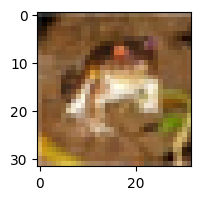

In [ ]:
plt.figure(figsize = (15,2))
plt.imshow(X_train[0])

In [ ]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [ ]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [ ]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [ ]:
def plot_sample(X,y,index):
  plt.figure(figsize = (15,2))
  plt.imshow(X[index])
  plt.xlabel(classes[y[index]])

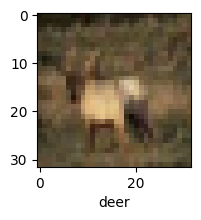

In [ ]:
plot_sample(X_train, y_train, 3)

In [ ]:
X_train = X_train / 255
X_test = X_test / 255

In [ ]:
ann = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000, activation="relu"),
    layers.Dense(1000, activation="relu"),
    layers.Dense(10, activation="sigmoid")
])

ann.compile(optimizer="SGD",
              loss="sparse_categorical_crossentropy",
              metrics = ["accuracy"])

ann.fit(X_train, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3035 - loss: 1.9354
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4182 - loss: 1.6394
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4535 - loss: 1.5494
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4795 - loss: 1.4905
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4962 - loss: 1.4368


In [ ]:
ann.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4819 - loss: 1.4589


[1.46303391456604, 0.47440001368522644]

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("classification report : \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
classification report : 
               precision    recall  f1-score   support

           0       0.42      0.71      0.53      1000
           1       0.74      0.36      0.48      1000
           2       0.36      0.40      0.38      1000
           3       0.39      0.19      0.26      1000
           4       0.52      0.28      0.36      1000
           5       0.41      0.44      0.42      1000
           6       0.48      0.64      0.55      1000
           7       0.48      0.62      0.54      1000
           8       0.68      0.49      0.57      1000
           9       0.48      0.62      0.54      1000

    accuracy                           0.47     10000
   macro avg       0.50      0.47      0.46     10000
weighted avg       0.50      0.47      0.46     10000



In [ ]:
cnn = models.Sequential([
    # cnn
    layers.Conv2D(filters=32, kernel_size=(3,3), activation="relu", input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    # dense
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.compile(optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=['accuracy'])

In [ ]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.3596 - loss: 1.7574
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5915 - loss: 1.1720
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6460 - loss: 1.0186
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6811 - loss: 0.9239
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6993 - loss: 0.8669
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7187 - loss: 0.8170
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7355 - loss: 0.7637
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7527 - loss: 0.7167
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7631 - loss: 0.6873
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7772 - loss: 0.6438


In [ ]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6996 - loss: 0.9065


[0.9064416885375977, 0.695900022983551]

In [ ]:
y_test = y_test.reshape(-1,)
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

In [ ]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[1.07667437e-02, 7.52590058e-05, 7.67178542e-04, 4.07450527e-01,
        2.32166052e-03, 8.34753364e-02, 3.90780158e-03, 2.26943498e-03,
        4.88248438e-01, 7.17681716e-04],
       [1.83682481e-03, 2.97709145e-02, 1.17977656e-07, 4.28136218e-07,
        7.44630881e-08, 3.16691073e-09, 1.00325814e-09, 7.73896502e-08,
        9.68089283e-01, 3.02276254e-04],
       [6.64018840e-03, 4.51568328e-03, 2.04277330e-05, 9.38037556e-06,
        4.70255400e-05, 6.56877603e-07, 5.55695976e-07, 7.88077705e-06,
        9.87694979e-01, 1.06326793e-03],
       [6.31107688e-01, 1.90356672e-02, 1.79157243e-03, 2.12187544e-04,
        2.70295655e-03, 1.80504539e-05, 1.08013082e-04, 4.72734100e-05,
        3.44805002e-01, 1.71697349e-04],
       [1.82721305e-06, 3.27494163e-05, 1.00010470e-03, 9.95469093e-03,
        1.76163204e-02, 3.20890860e-04, 9.71063614e-01, 6.84899192e-07,
        7.92589435e-06, 1.15938337e-06]], dtype=float32)

In [ ]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(8), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

In [ ]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

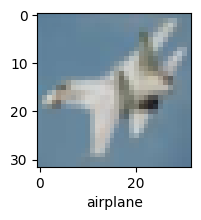

In [ ]:
plot_sample(X_test, y_test, 10)

In [ ]:
classes[y_classes[10]]

'airplane'